In [1]:
import pickle
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('dump3.csv')

In [3]:
data.shape

(83707, 5)

In [4]:
data.head(5)

,name,Артикул,category,Цена без карты,Цена с картой
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽


In [5]:
print(data['category'].unique(), len(data['category'].unique()))

['Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли'
 'Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели'
 'Главная,Каталог,Строительные материалы,Кровля,Металлочерепица'
 'Главная,Каталог,Строительные материалы,Кровля,Мягкая черепица'
 'Главная,Каталог,Строительные материалы,Кровля,Профнастил'
 'Главная,Каталог,Строительные материалы,Кровля,Рулонная кровля'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Клеи'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Ровнители для пола'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Специальные смеси'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Шпаклевки'
 'Главная,Катал

In [6]:
print(data['name'].unique(), len(data['name'].unique()))

['Проходка BORGE Кровельная D6-50мм прямая №1' 'Аэратор ТЕХНОНИКОЛЬ КТВ'
 'Аэратор ТЕХНОНИКОЛЬ Pilot скатный' ...
 'Решётка заборная FULEREN 15х15 0,5х5мх'
 'Решётка заборная FULEREN 15х15 0,5х10м'
 'Сетка сварная FULEREN Оцинкованная 50х100 1,8х15м'] 82921


# Выборка данных

In [7]:
topics = set(data.category)
pack_in_cat = 170

In [8]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['category'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic)

  0%|          | 0/872 [00:00<?, ?it/s]

In [9]:
df_res.head(30)

,name,Артикул,category,Цена без карты,Цена с картой
38136,Плинтус потолочный ПЛАСТКОМ дуб 3м,20394401,"Главная,Каталог,Потолочные и стеновые покрытия...",69.00 ₽,65.55 ₽
38137,Плинтус потолочный ЛАГОМ 13009,23717,"Главная,Каталог,Потолочные и стеновые покрытия...",63.00 ₽,59.85 ₽
38138,Плинтус потолочный ЛАГОМ 13005,21549,"Главная,Каталог,Потолочные и стеновые покрытия...",41.00 ₽,38.95 ₽
38139,Плинтус потолочный DECOMASTER DP-5040,10785901,"Главная,Каталог,Потолочные и стеновые покрытия...",3 699.00 ₽,3 514.05 ₽
38140,Плинтус потолочный ЛАГОМ 12011,72979,"Главная,Каталог,Потолочные и стеновые покрытия...",39.00 ₽,37.05 ₽
38141,Плинтус потолочный DECOMASTER DP-377,10785801,"Главная,Каталог,Потолочные и стеновые покрытия...",1 349.00 ₽,1 281.55 ₽
38142,Плинтус потолочный DECOMASTER 96257,17898801,"Главная,Каталог,Потолочные и стеновые покрытия...",735.00 ₽,698.25 ₽
38143,Плинтус потолочный DECOMASTER Flexible 96406,17903701,"Главная,Каталог,Потолочные и стеновые покрытия...",2 899.00 ₽,2 754.05 ₽
38144,Плинтус DECOMASTER 175-6,11813501,"Главная,Каталог,Потолочные и стеновые покрытия...",1 499.00 ₽,1 424.05 ₽
38145,Плинтус потолочный DECOMASTER DP-5041,10786001,"Главная,Каталог,Потолочные и стеновые покрытия...",4 099.00 ₽,3 894.05 ₽



# Предобработка

In [10]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-11-6083d33376df>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


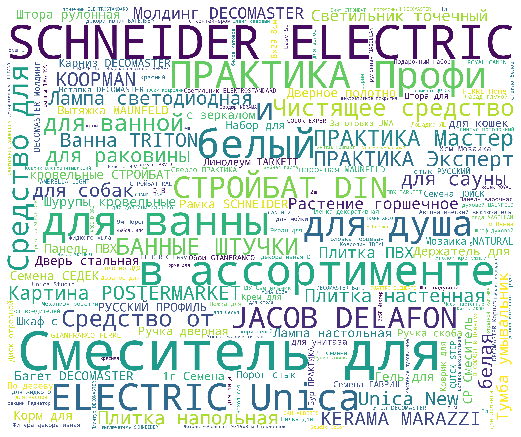

In [11]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['name'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [12]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['name'])]


  0%|          | 0/50258 [00:00<?, ?it/s]

In [13]:
len(prep_text)
prep_text[1]

'плинтус потолочный лагом '

In [14]:
df_res['text_prep'] = prep_text
df_res.head(1)

,name,Артикул,category,Цена без карты,Цена с картой,text_prep
38136,Плинтус потолочный ПЛАСТКОМ дуб 3м,20394401,"Главная,Каталог,Потолочные и стеновые покрытия...",69.00 ₽,65.55 ₽,плинтус потолочный пластком дуб м


In [15]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [16]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [17]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['проходка', 'borge', 'кровельная', 'd', 'мм', 'прямая', '№']

In [18]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

  0%|          | 0/50258 [00:00<?, ?it/s]

In [19]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [20]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

  0%|          | 0/50258 [00:00<?, ?it/s]

In [21]:
df_res['text_sw'][0]

'проходка borge кровельная d мм прямая №'

In [22]:
df_res.to_csv('sp_stemmed.csv')

In [23]:
df_res['text_stem'][0]

'проходк borge кровельн d мм прям №'

# Лемматизация

In [24]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

  0%|          | 0/50258 [00:00<?, ?it/s]

In [25]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [26]:
df_res.to_csv('lemm.csv')

In [27]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [28]:
df_res.head()

,Unnamed: 0,name,Артикул,category,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,38136,Плинтус потолочный ПЛАСТКОМ дуб 3м,20394401,"Главная,Каталог,Потолочные и стеновые покрытия...",69.00 ₽,65.55 ₽,плинтус потолочный пластком дуб м,плинтус потолочн пластк дуб м,плинтус потолочный пластком дуб м,плинтус потолочный пласток дуб м \n
1,38137,Плинтус потолочный ЛАГОМ 13009,23717,"Главная,Каталог,Потолочные и стеновые покрытия...",63.00 ₽,59.85 ₽,плинтус потолочный лагом,плинтус потолочн лаг,плинтус потолочный лагом,плинтус потолочный лаг \n
2,38138,Плинтус потолочный ЛАГОМ 13005,21549,"Главная,Каталог,Потолочные и стеновые покрытия...",41.00 ₽,38.95 ₽,плинтус потолочный лагом,плинтус потолочн лаг,плинтус потолочный лагом,плинтус потолочный лаг \n
3,38139,Плинтус потолочный DECOMASTER DP-5040,10785901,"Главная,Каталог,Потолочные и стеновые покрытия...",3 699.00 ₽,3 514.05 ₽,плинтус потолочный decomaster dp,плинтус потолочн decomaster dp,плинтус потолочный decomaster dp,плинтус потолочный decomaster dp \n
4,38140,Плинтус потолочный ЛАГОМ 12011,72979,"Главная,Каталог,Потолочные и стеновые покрытия...",39.00 ₽,37.05 ₽,плинтус потолочный лагом,плинтус потолочн лаг,плинтус потолочный лагом,плинтус потолочный лаг \n


In [29]:
df_res['text_lemm'][0]

'плинтус потолочный пласток дуб м \n'

In [30]:
X = df_res['text_sw']
y = df_res['category']

In [31]:
type(df_res['text_lemm'][0])

str

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.9 , random_state = 127)

In [41]:
my_cat = df_res['category'].unique()
my_cat

array(['Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Плинтуса потолочные',
       'Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Металлопластиковые трубы и фитинги',
       'Главная,Каталог,Сауны и бани,Аксессуары для саун и бань,Термометры и гигрометры для сауны',
       'Главная,Каталог,Сад и огород,Агрохимия,Стимуляторы роста, корнеобразования и завязи',
       'Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Бытовая техника,Мини-печи',
       'Главная,Каталог,Отопление, водоснабжение, канализация,Системы отопления и ГВС,Решётки радиаторные',
       'Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Карнизы',
       'Главная,Каталог,Товары для дома, подарки, бытовая химия,Товары для животных,Расчёски, пуходёрки',
       'Главная,Каталог,Сад и огород,Поливочные системы,Пистолеты и наконечники для полива, опрыскиватели',
       'Главная,Каталог,Сад и огород,Садовый электро-бензоинструмент,Вод

In [42]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [43]:
nb = Pipeline([('vect', CountVectorizer()),
               ('tfidf', TfidfTransformer()),
               ('clf', MultinomialNB()),
              ])

In [44]:
%%time
nb.fit(X_train, y_train)

CPU times: user 266 ms, sys: 56.4 ms, total: 323 ms
Wall time: 322 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [45]:
%%time
from sklearn.metrics import classification_report
y_pred = nb.predict(X_test)

CPU times: user 534 ms, sys: 149 ms, total: 683 ms
Wall time: 684 ms


In [46]:
y_pred[0]

'Главная,Каталог,Сантехника, мебель для ванной комнаты,Санфаянс,Раковины'

In [47]:
print(X_test[0], y_test[0], y_pred[0])

плинтус потолочный пластком дуб м Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Плинтуса потолочные Главная,Каталог,Сантехника, мебель для ванной комнаты,Санфаянс,Раковины


In [48]:
from sklearn.metrics import accuracy_score

print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.5318683262220061


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                  Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Плинтуса потолочные       0.97      0.28      0.43       111
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Металлопластиковые трубы и фитинги       0.00      0.00      0.00        36
                                                Главная,Каталог,Сауны и бани,Аксессуары для саун и бань,Термометры и гигрометры для сауны       0.98      0.89      0.93        64
                                                      Главная,Каталог,Сад и огород,Агрохимия,Стимуляторы роста, корнеобразования и завязи       0.00      0.00      0.00         2
                                                       Главная,Каталог,Кухни, мойки, смесители, бытовая 

In [49]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=5, tol=None)),
               ])

In [50]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 1.56 s, sys: 24 ms, total: 1.59 s
Wall time: 1.61 s


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=5, random_state=42,
                               tol=None))])

In [51]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 605 ms, sys: 125 ms, total: 729 ms
Wall time: 728 ms


In [52]:
from sklearn.metrics import accuracy_score
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.7504697897552671


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                  Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Плинтуса потолочные       0.55      0.58      0.56       111
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Металлопластиковые трубы и фитинги       0.83      0.83      0.83        36
                                                Главная,Каталог,Сауны и бани,Аксессуары для саун и бань,Термометры и гигрометры для сауны       0.42      0.98      0.59        64
                                                      Главная,Каталог,Сад и огород,Агрохимия,Стимуляторы роста, корнеобразования и завязи       0.00      0.00      0.00         2
                                                       Главная,Каталог,Кухни, мойки, смесители, бытовая 

In [53]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=3, tol=None)),
               ])

In [54]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 1.33 s, sys: 0 ns, total: 1.33 s
Wall time: 1.33 s


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=3, random_state=42,
                               tol=None))])

In [55]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 546 ms, sys: 200 ms, total: 746 ms
Wall time: 750 ms


In [56]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.7426657528795348


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                  Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Плинтуса потолочные       0.50      0.56      0.53       111
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Металлопластиковые трубы и фитинги       0.79      0.83      0.81        36
                                                Главная,Каталог,Сауны и бани,Аксессуары для саун и бань,Термометры и гигрометры для сауны       0.41      0.98      0.58        64
                                                      Главная,Каталог,Сад и огород,Агрохимия,Стимуляторы роста, корнеобразования и завязи       0.00      0.00      0.00         2
                                                       Главная,Каталог,Кухни, мойки, смесители, бытовая 

In [57]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(n_jobs=1, C=1e5)),
               ])

In [58]:
%%time
logreg.fit(X_train, y_train)

CPU times: user 1min 50s, sys: 8.06 s, total: 1min 58s
Wall time: 1min 58s


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(C=100000.0, n_jobs=1))])

In [59]:
%%time
y_pred = logreg.predict(X_test)

CPU times: user 598 ms, sys: 124 ms, total: 722 ms
Wall time: 721 ms


In [60]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.7983993986691132


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                  Главная,Каталог,Потолочные и стеновые покрытия,Декоративный потолок,Плинтуса потолочные       0.67      0.65      0.66       111
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Металлопластиковые трубы и фитинги       0.68      1.00      0.81        36
                                                Главная,Каталог,Сауны и бани,Аксессуары для саун и бань,Термометры и гигрометры для сауны       0.83      0.98      0.90        64
                                                      Главная,Каталог,Сад и огород,Агрохимия,Стимуляторы роста, корнеобразования и завязи       0.00      0.00      0.00         2
                                                       Главная,Каталог,Кухни, мойки, смесители, бытовая 

In [61]:
test_text = 'гвозди'

In [62]:
test_text = lemmatize_text(remove_stop_words(remove_multiple_spaces(remove_numbers(remove_punctuation(test_text.lower())))))
test_text

'гвоздь \n'

In [88]:
pickle_out = open("lemm.pkl", "wb")
pickle.dump(lemmatize_text, pickle_out)
pickle_out.close()

In [89]:
pickle_out = open("stop_words.pkl", "wb")
pickle.dump(remove_stop_words, pickle_out)
pickle_out.close()

In [90]:
pickle_out = open("remove_spaces.pkl", "wb")
pickle.dump(remove_multiple_spaces, pickle_out)
pickle_out.close()

In [91]:
pickle_out = open("remove_numbers.pkl", "wb")
pickle.dump(remove_numbers, pickle_out)
pickle_out.close()

In [92]:
pickle_out = open("r_p.pkl", "wb")
pickle.dump(remove_punctuation, pickle_out)
pickle_out.close()

In [93]:
pickle_in = open("lemm.pkl", "rb")
lemm = pickle.load(pickle_in)

In [94]:
pickle_in = open("stop_words.pkl", "rb")
sp = pickle.load(pickle_in)

In [95]:
pickle_in = open("remove_spaces.pkl", "rb")
rs = pickle.load(pickle_in)

In [96]:
pickle_in = open("remove_numbers.pkl", "rb")
rn = pickle.load(pickle_in)

In [97]:
pickle_in = open("r_p.pkl", "rb")
rp = pickle.load(pickle_in)

In [98]:
name = rp(name).lower()
name = rn(name)
name = rs(name)
name = sp(name)
name = lemm(name)
name

'газоразрядный \n'

In [77]:
test

'газоразрядная'

In [63]:
%%time
test_text = lemmatize_text(test_text)

CPU times: user 608 µs, sys: 33 µs, total: 641 µs
Wall time: 420 µs


In [64]:
test_text

'гвоздь  \n'

In [65]:
test_pred = nb.predict([test_text])
test_pred

array(['Главная,Каталог,Хранение и порядок,Хранение,Навесные полки и крепления'],
      dtype='<U137')

In [66]:
test_pred = sgd.predict([test_text])
test_pred

array(['Главная,Каталог,Инструменты и крепёж,Специальный инструмент и оборудование,Паяльники'],
      dtype='<U137')

In [67]:
test_pred = logreg.predict([test_text]) #logreg.predict определяет хуже чем sgd.predict про nb.predict я вообщепромолчу точность 49
test_pred

array(['Главная,Каталог,Инструменты и крепёж,Столярно-слесарный инструмент,Крепления для инструментов'],
      dtype=object)

In [434]:
# но если и выбирать то только из последних двух

In [435]:
#pickle_out = open("classificate.pkl", "wb")
#pickle.dump(logreg, pickle_out)
#pickle_out.close()

In [436]:
#logreg.predict(['зеленый конек ондулин'])

array(['Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'],
      dtype=object)

In [13]:
pickle_in = open("classificate.pkl", "rb")
classificate = pickle.load(pickle_in)

In [71]:
name = 'газоразрядная'